# 04 — Full Model Runs: Corruption Sweep

This notebook runs the full experiment matrix described in the README:

- **8 corruption types**: none (control), JPEG compression, beam hardening, Gaussian noise, Gibbs ringing, motion ghosting, Rician noise, and combination (all 5 MRI corruptions split equally)
- **3 training corruption fractions**: 0%, 10%, 25%
- **6 test corruption fractions**: 0%, 10%, 25%, 50%, 75%, 100%
- **3 pretrained models**: ResNet18, ResNet50, DenseNet121

Results are saved incrementally to `outputs/model_runs/` so the notebook can be interrupted and resumed.

**Note:** The "none" (control) corruption only runs once (train=0%, test=0%) since all fractions produce identical results.

## 1. Imports & Setup

In [2]:
import sys
import copy
import json
import random
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader

from preprocessing import (
    BrainTumorDataset,
    CLASS_NAMES,
    get_transform,
    load_split,
)
from model import get_model, MODEL_REGISTRY
from corruption_utils import CORRUPTION_REGISTRY, apply_corruption

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Available models: {list(MODEL_REGISTRY)}")
print(f"Available corruptions: {list(CORRUPTION_REGISTRY)}")
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

Device: cuda
Available models: ['resnet18', 'resnet50', 'densenet121']
Available corruptions: ['jpeg_compression', 'gaussian_noise', 'rician_noise', 'gibbs_ringing', 'motion_ghosting', 'beam_hardening', 'stain_variation', 'tissue_fold', 'air_bubble']
Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Configuration

Edit the variables below to control the experiment scope. You can run a subset of models or corruption types to get partial results first.

In [3]:
# =====================================================================
# CONFIGURATION
# =====================================================================

# Which model(s) to train. Options: "resnet18", "resnet50", "densenet121"
MODEL_NAMES = ["resnet18", "resnet50", "densenet121"]

# Corruption types for training data.
# "none" = clean data (control baseline, runs once regardless of fractions).
# "combination" = corrupted portion split equally across all 5 MRI corruption types.
CORRUPTION_TYPES = [
    "none",
    "jpeg_compression",
    "beam_hardening",
    "gaussian_noise",
    "gibbs_ringing",
    "motion_ghosting",
    "rician_noise",
    "combination",
]

# Fraction of training data to corrupt
TRAIN_FRACTIONS = [0.0, 0.10, 0.25]

# Fraction of test data to corrupt during evaluation
TEST_FRACTIONS = [0.0, 0.10, 0.25, 0.50, 0.75, 1.0]

# Training hyperparameters
NUM_EPOCHS = 15
BATCH_SIZE = 32
LR = 1e-4
WEIGHT_DECAY = 1e-4

# Output directory
RESULTS_DIR = PROJECT_ROOT / "outputs" / "model_runs"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Build the experiment list
# "none" only needs one run (train_frac=0, test_frac=0) since all fractions are identical
experiments_per_model = []
for ct in CORRUPTION_TYPES:
    if ct == "none":
        experiments_per_model.append((ct, 0.0, [0.0]))
    else:
        for tf in TRAIN_FRACTIONS:
            experiments_per_model.append((ct, tf, TEST_FRACTIONS))

n_trainings = len(experiments_per_model)
n_evals = sum(len(tfs) for _, _, tfs in experiments_per_model)
print(f"Models:              {MODEL_NAMES}")
print(f"Corruption types:    {len(CORRUPTION_TYPES)}")
print(f"Training fractions:  {TRAIN_FRACTIONS}")
print(f"Test fractions:      {TEST_FRACTIONS}")
print(f"---")
print(f"Trainings per model: {n_trainings}")
print(f"Evaluations per model: {n_evals}")
print(f"Total trainings:     {n_trainings * len(MODEL_NAMES)}")
print(f"Total evaluations:   {n_evals * len(MODEL_NAMES)}")

Models:              ['resnet18', 'resnet50', 'densenet121']
Corruption types:    8
Training fractions:  [0.0, 0.1, 0.25]
Test fractions:      [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
---
Trainings per model: 22
Evaluations per model: 127
Total trainings:     66
Total evaluations:   381


## 3. Corruption Datasets & DataLoader Helpers

Three dataset variants:
- **Clean** — used when corruption is `"none"` or fraction is 0
- **Single corruption** — corrupts a random subset with one corruption type
- **Combination** — splits the corrupted subset equally across all 5 MRI corruptions

In [4]:
# The 5 MRI-relevant corruption types used in the "combination" condition
COMBINATION_CORRUPTIONS = [
    "beam_hardening",
    "gaussian_noise",
    "gibbs_ringing",
    "motion_ghosting",
    "rician_noise",
]


class CorruptedBrainTumorDataset(BrainTumorDataset):
    """Corrupts a random fraction of samples with a single corruption type."""

    def __init__(self, samples, transform, corruption_name, corruption_fraction=0.0, seed=42):
        super().__init__(samples, transform)
        self.corruption_name = corruption_name
        n_corrupt = int(len(samples) * corruption_fraction)
        rng = random.Random(seed)
        all_indices = list(range(len(samples)))
        rng.shuffle(all_indices)
        self.corrupted_indices = set(all_indices[:n_corrupt])

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        if idx in self.corrupted_indices:
            image = apply_corruption(image, self.corruption_name)
        if self.transform is not None:
            image = self.transform(image)
        return image, label


class CombinedCorruptionDataset(BrainTumorDataset):
    """Splits the corrupted portion equally across all 5 MRI corruption types."""

    def __init__(self, samples, transform, corruption_fraction=0.0, seed=42):
        super().__init__(samples, transform)
        n_corrupt = int(len(samples) * corruption_fraction)
        rng = random.Random(seed)
        all_indices = list(range(len(samples)))
        rng.shuffle(all_indices)
        corrupt_indices = all_indices[:n_corrupt]

        # Assign each corrupted index to one of the 5 corruption types
        self.index_to_corruption = {}
        chunk_size = max(1, len(corrupt_indices) // len(COMBINATION_CORRUPTIONS))
        for i, corruption_name in enumerate(COMBINATION_CORRUPTIONS):
            start = i * chunk_size
            end = start + chunk_size if i < len(COMBINATION_CORRUPTIONS) - 1 else len(corrupt_indices)
            for idx in corrupt_indices[start:end]:
                self.index_to_corruption[idx] = corruption_name

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        if idx in self.index_to_corruption:
            image = apply_corruption(image, self.index_to_corruption[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_dataloader(split, corruption_type, corruption_fraction, batch_size):
    """Build a DataLoader with the specified corruption settings."""
    samples = load_split(split)
    transform = get_transform(split)

    if corruption_type == "none" or corruption_fraction == 0.0:
        dataset = BrainTumorDataset(samples, transform)
    elif corruption_type == "combination":
        dataset = CombinedCorruptionDataset(
            samples, transform,
            corruption_fraction=corruption_fraction, seed=SEED,
        )
    else:
        dataset = CorruptedBrainTumorDataset(
            samples, transform,
            corruption_name=corruption_type,
            corruption_fraction=corruption_fraction, seed=SEED,
        )

    return DataLoader(
        dataset, batch_size=batch_size,
        shuffle=(split == "train"), num_workers=0,
    )


print("Dataset helpers ready.")

Dataset helpers ready.


## 4. Training & Evaluation

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns (avg loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_with_predictions(model, loader, criterion, device):
    """Evaluate model and collect all predictions. Returns (loss, acc, all_preds, all_labels)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return running_loss / total, correct / total, all_preds, all_labels


def run_single_experiment(model_name, corruption_type, train_fraction,
                          test_fractions, num_epochs, batch_size, lr,
                          weight_decay, device):
    """Train one model config and evaluate on all specified test fractions.

    Returns a dict with training history and per-test-fraction results
    (including per-class accuracy).
    """
    train_loader = build_dataloader("train", corruption_type, train_fraction, batch_size)
    val_loader = build_dataloader("val", "none", 0.0, batch_size)  # always validate on clean

    model = get_model(model_name).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = []
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == num_epochs:
            print(f"    Epoch {epoch:>3}/{num_epochs} \u2014 "
                  f"train_acc: {train_acc:.3f} | val_acc: {val_acc:.3f} | {elapsed:.1f}s")

    # Load best model for test evaluation
    model.load_state_dict(best_model_state)

    # Evaluate on test set at each corruption fraction (with per-class predictions)
    test_results = {}
    for test_frac in test_fractions:
        test_loader = build_dataloader("test", corruption_type, test_frac, batch_size)
        test_loss, test_acc, preds, labels = evaluate_with_predictions(
            model, test_loader, criterion, device
        )
        # Per-class accuracy
        per_class = {}
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            cls_mask = [i for i, l in enumerate(labels) if l == cls_idx]
            if cls_mask:
                cls_correct = sum(1 for i in cls_mask if preds[i] == labels[i])
                per_class[cls_name] = cls_correct / len(cls_mask)
            else:
                per_class[cls_name] = 0.0

        test_results[str(test_frac)] = {
            "test_loss": test_loss,
            "test_acc": test_acc,
            "per_class_acc": per_class,
            "predictions": preds,
            "labels": labels,
        }
        print(f"    Test ({test_frac:>5.0%} corrupted): acc={test_acc:.4f}")

    return {
        "model_name": model_name,
        "corruption_type": corruption_type,
        "train_fraction": train_fraction,
        "best_val_acc": best_val_acc,
        "history": history,
        "test_results": test_results,
    }


print("Training functions ready.")

Training functions ready.


## 5. Run Full Sweep

Iterates over every `(model, corruption_type, train_fraction)` combination, trains the model, and evaluates on all test fractions. Results are saved to JSON after each experiment so you can interrupt and resume safely.

In [6]:
def get_results_path(model_name):
    return RESULTS_DIR / f"{model_name}_full_results.json"


def load_existing_results(model_name):
    path = get_results_path(model_name)
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}


def save_results(model_name, all_results):
    path = get_results_path(model_name)
    with open(path, "w") as f:
        json.dump(all_results, f, indent=2)


def make_key(corruption_type, train_fraction):
    return f"{corruption_type}__train{train_fraction:.2f}"


# ---------- Main sweep ----------
sweep_start = time.time()

for model_name in MODEL_NAMES:
    print(f"\n{'='*70}")
    print(f"  MODEL: {model_name}")
    print(f"{'='*70}")

    all_results = load_existing_results(model_name)
    total = len(experiments_per_model)

    for i, (corruption_type, train_fraction, test_fracs) in enumerate(experiments_per_model, 1):
        key = make_key(corruption_type, train_fraction)

        if key in all_results:
            print(f"\n  [{i}/{total}] SKIP (done): {key}")
            continue

        print(f"\n  [{i}/{total}] {model_name} | {corruption_type} | train={train_fraction:.0%}")

        result = run_single_experiment(
            model_name=model_name,
            corruption_type=corruption_type,
            train_fraction=train_fraction,
            test_fractions=test_fracs,
            num_epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            device=DEVICE,
        )

        all_results[key] = result
        save_results(model_name, all_results)
        print(f"    Saved. Best val acc: {result['best_val_acc']:.4f}")

    print(f"\n  {model_name}: {total} experiments complete.")
    print(f"  Results: {get_results_path(model_name)}")

sweep_elapsed = time.time() - sweep_start
print(f"\n{'='*70}")
print(f"ALL SWEEPS COMPLETE  ({sweep_elapsed/60:.1f} min)")
print(f"{'='*70}")


  MODEL: resnet18

  [1/22] SKIP (done): none__train0.00

  [2/22] SKIP (done): jpeg_compression__train0.00

  [3/22] SKIP (done): jpeg_compression__train0.10

  [4/22] SKIP (done): jpeg_compression__train0.25

  [5/22] SKIP (done): beam_hardening__train0.00

  [6/22] SKIP (done): beam_hardening__train0.10

  [7/22] SKIP (done): beam_hardening__train0.25

  [8/22] SKIP (done): gaussian_noise__train0.00

  [9/22] SKIP (done): gaussian_noise__train0.10

  [10/22] SKIP (done): gaussian_noise__train0.25

  [11/22] SKIP (done): gibbs_ringing__train0.00

  [12/22] SKIP (done): gibbs_ringing__train0.10

  [13/22] SKIP (done): gibbs_ringing__train0.25

  [14/22] SKIP (done): motion_ghosting__train0.00

  [15/22] SKIP (done): motion_ghosting__train0.10

  [16/22] SKIP (done): motion_ghosting__train0.25

  [17/22] SKIP (done): rician_noise__train0.00

  [18/22] SKIP (done): rician_noise__train0.10

  [19/22] SKIP (done): rician_noise__train0.25

  [20/22] SKIP (done): combination__train0.00

  

## 6. Load & Analyze Results

In [7]:
import pandas as pd


def load_all_results():
    """Load all saved results into a flat DataFrame."""
    rows = []
    for model_name in MODEL_NAMES:
        path = get_results_path(model_name)
        if not path.exists():
            print(f"  Warning: no results for {model_name}")
            continue
        with open(path) as f:
            data = json.load(f)
        for key, result in data.items():
            for test_frac_str, test_res in result["test_results"].items():
                rows.append({
                    "model": result["model_name"],
                    "corruption_type": result["corruption_type"],
                    "train_fraction": result["train_fraction"],
                    "test_fraction": float(test_frac_str),
                    "best_val_acc": result["best_val_acc"],
                    "test_acc": test_res["test_acc"],
                    "test_loss": test_res["test_loss"],
                })
    return pd.DataFrame(rows)


df = load_all_results()
print(f"Total result rows: {len(df)}")
print(f"Models: {sorted(df['model'].unique())}")
print(f"Corruption types: {sorted(df['corruption_type'].unique())}")
print(f"Train fractions: {sorted(df['train_fraction'].unique())}")
print(f"Test fractions: {sorted(df['test_fraction'].unique())}")

# Summary: best validation accuracy per model x corruption x train_frac
pivot_val = df.drop_duplicates(
    subset=["model", "corruption_type", "train_fraction"]
).pivot_table(
    index=["corruption_type", "train_fraction"],
    columns="model",
    values="best_val_acc",
    aggfunc="first",
)
print("\n=== Best Validation Accuracy ===")
print(pivot_val.to_string(float_format="{:.4f}".format))

Total result rows: 381
Models: ['densenet121', 'resnet18', 'resnet50']
Corruption types: ['beam_hardening', 'combination', 'gaussian_noise', 'gibbs_ringing', 'jpeg_compression', 'motion_ghosting', 'none', 'rician_noise']
Train fractions: [np.float64(0.0), np.float64(0.1), np.float64(0.25)]
Test fractions: [np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]

=== Best Validation Accuracy ===
model                            densenet121  resnet18  resnet50
corruption_type  train_fraction                                 
beam_hardening   0.00                 0.9938    0.9911    0.9920
                 0.10                 0.9938    0.9938    0.9929
                 0.25                 0.9893    0.9929    0.9902
combination      0.00                 0.9938    0.9920    0.9902
                 0.10                 0.9911    0.9911    0.9920
                 0.25                 0.9929    0.9920    0.9902
gaussian_noise   0.00             

## 7. Visualization: Test Accuracy vs Test Corruption

For each model, plot test accuracy as a function of test corruption fraction. Each subplot is one corruption type, with separate lines for each training fraction.

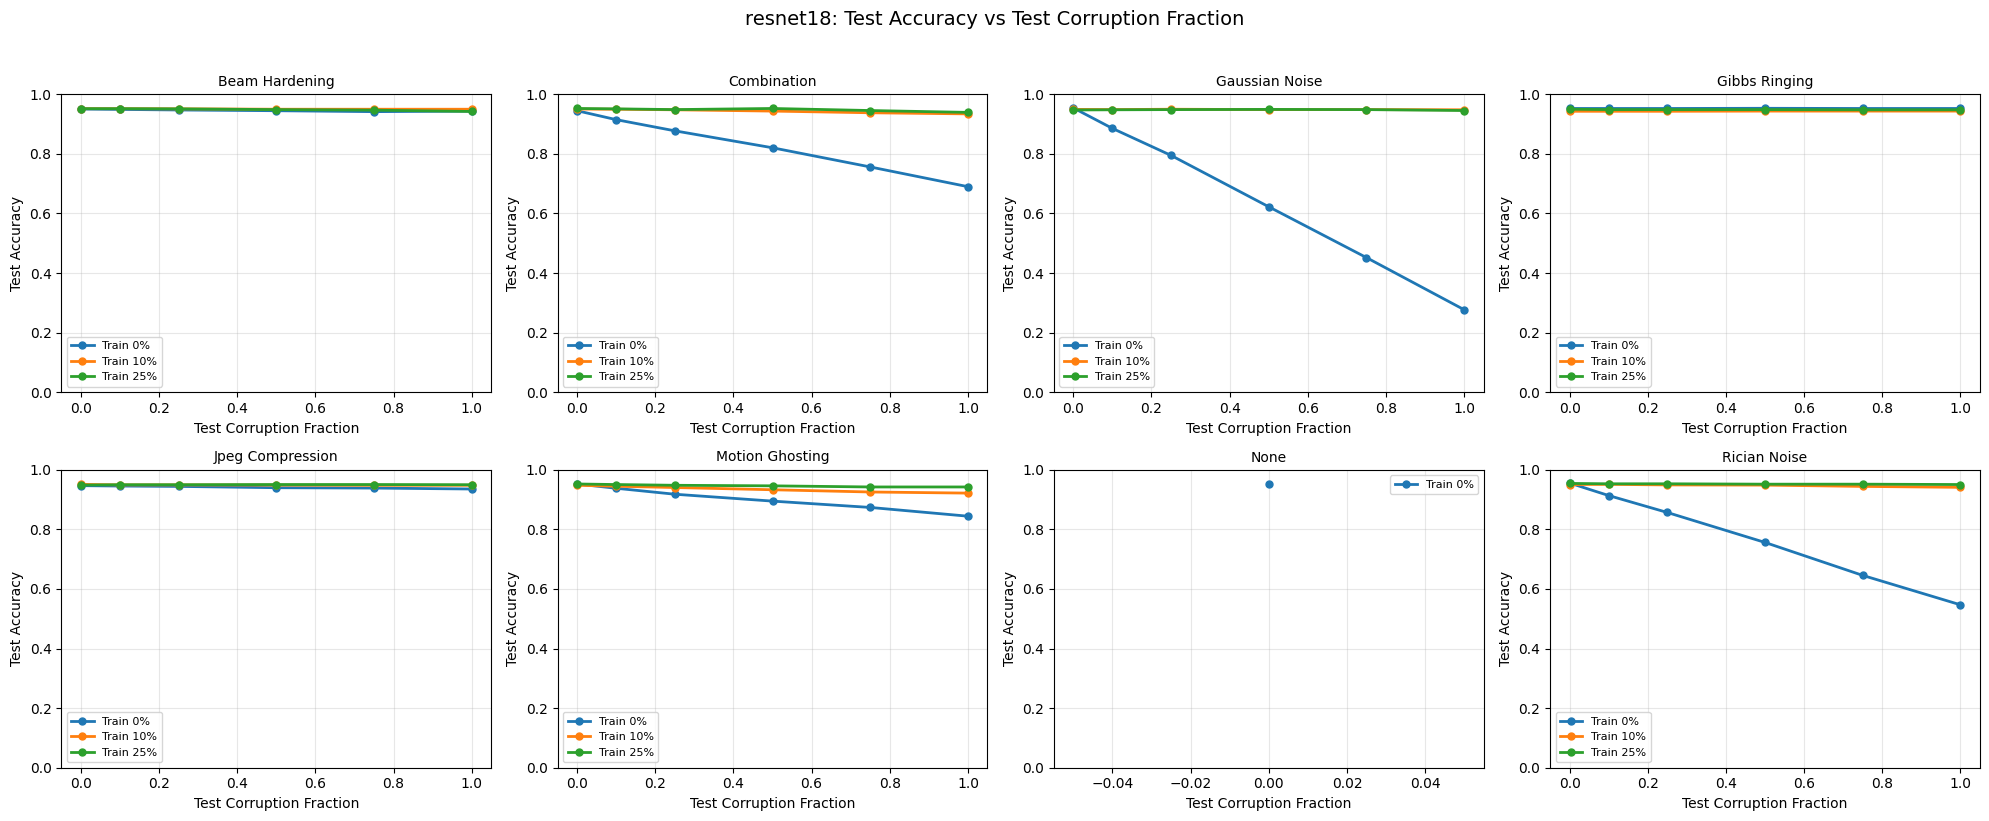

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_corruption_comparison.png


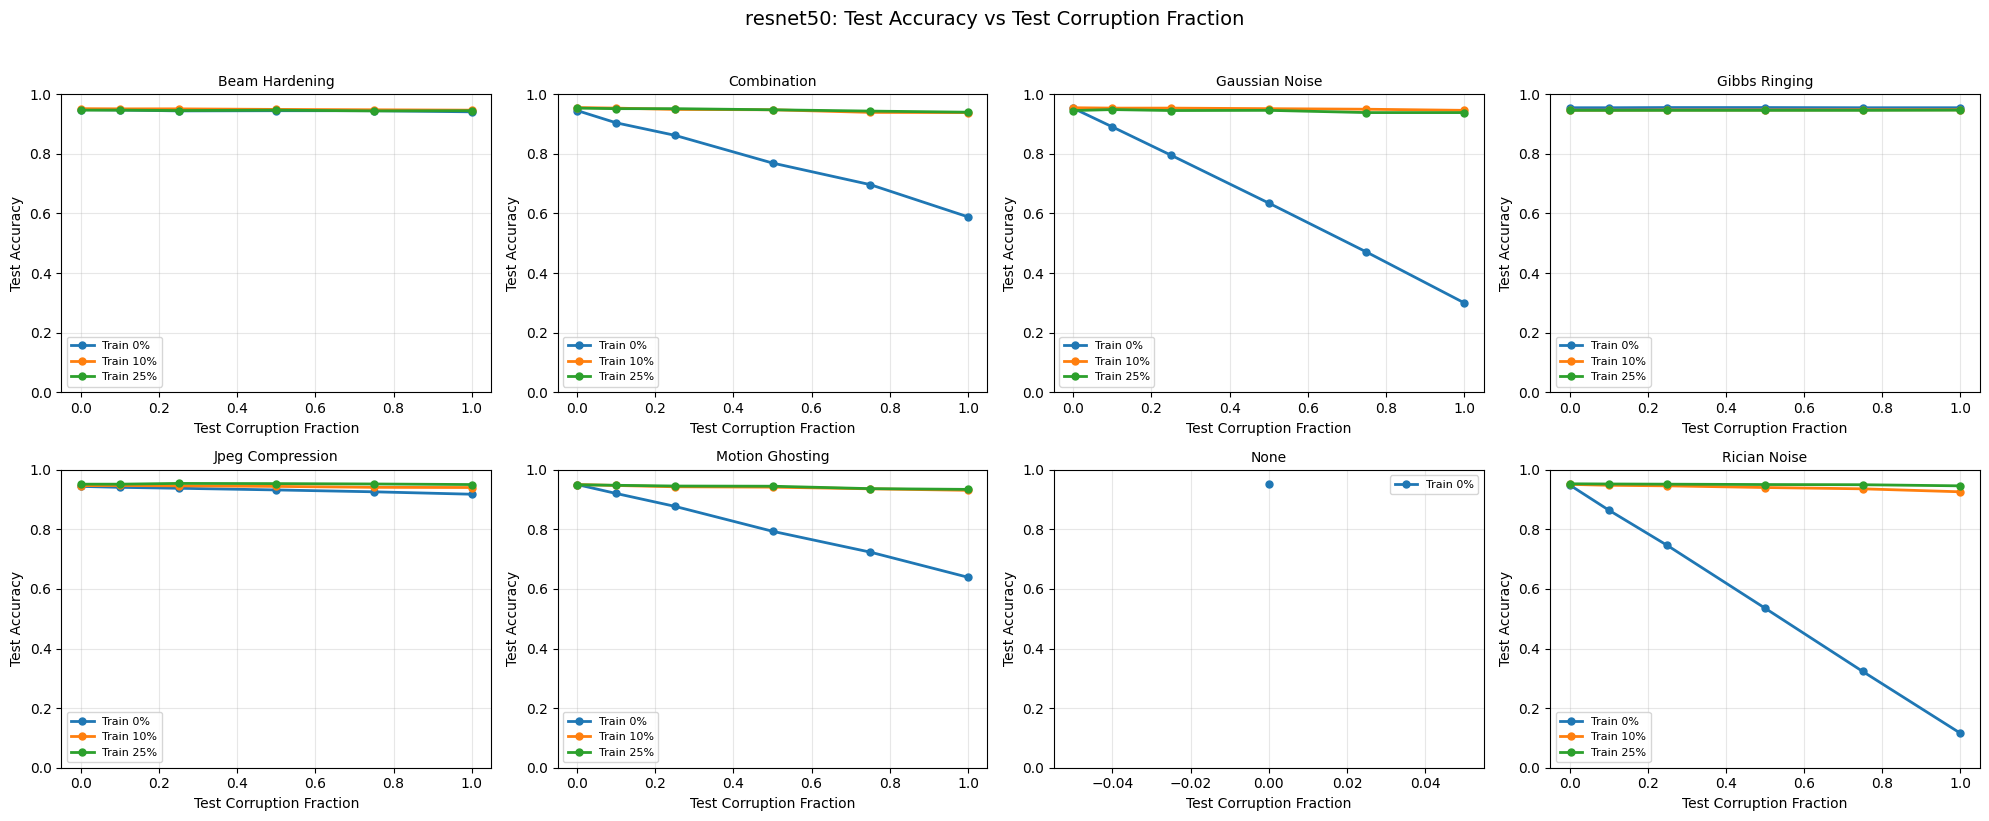

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet50_corruption_comparison.png


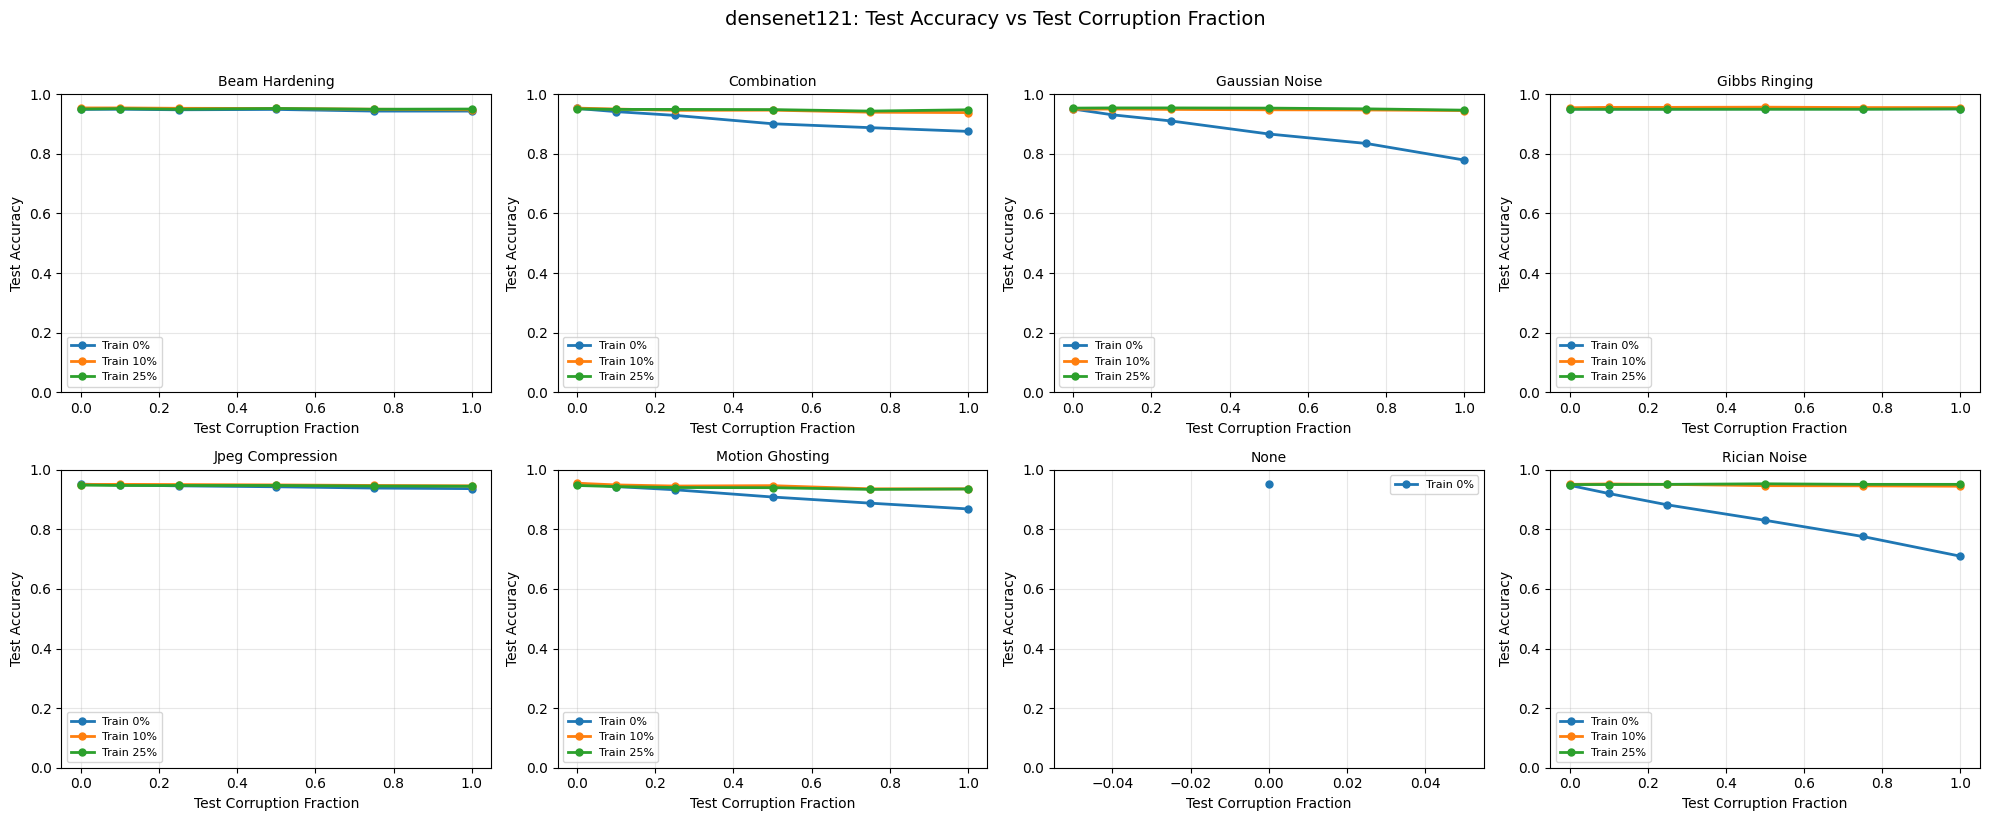

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\densenet121_corruption_comparison.png


In [8]:
import matplotlib.pyplot as plt


def plot_corruption_comparison(df, model_name):
    """One subplot per corruption type showing test acc vs test corruption %."""
    model_df = df[df["model"] == model_name]
    corruption_types = sorted(model_df["corruption_type"].unique())
    n = len(corruption_types)
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    fig.suptitle(f"{model_name}: Test Accuracy vs Test Corruption Fraction",
                 fontsize=14, y=1.02)

    for idx, ct in enumerate(corruption_types):
        ax = axes[idx // cols][idx % cols]
        ct_df = model_df[model_df["corruption_type"] == ct]

        for tf in sorted(ct_df["train_fraction"].unique()):
            subset = ct_df[ct_df["train_fraction"] == tf].sort_values("test_fraction")
            ax.plot(subset["test_fraction"], subset["test_acc"],
                    "o-", linewidth=2, markersize=5, label=f"Train {tf:.0%}")

        ax.set_title(ct.replace("_", " ").title(), fontsize=10)
        ax.set_xlabel("Test Corruption Fraction")
        ax.set_ylabel("Test Accuracy")
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    for idx in range(n, rows * cols):
        axes[idx // cols][idx % cols].set_visible(False)

    plt.tight_layout()
    plot_path = RESULTS_DIR / f"{model_name}_corruption_comparison.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {plot_path}")


for model_name in df["model"].unique():
    plot_corruption_comparison(df, model_name)

## 8. Visualization: Robustness Heatmap

Shows the accuracy drop from clean test data (0%) to fully corrupted test data (100%) for each corruption type and training fraction. Smaller gaps = more robust.

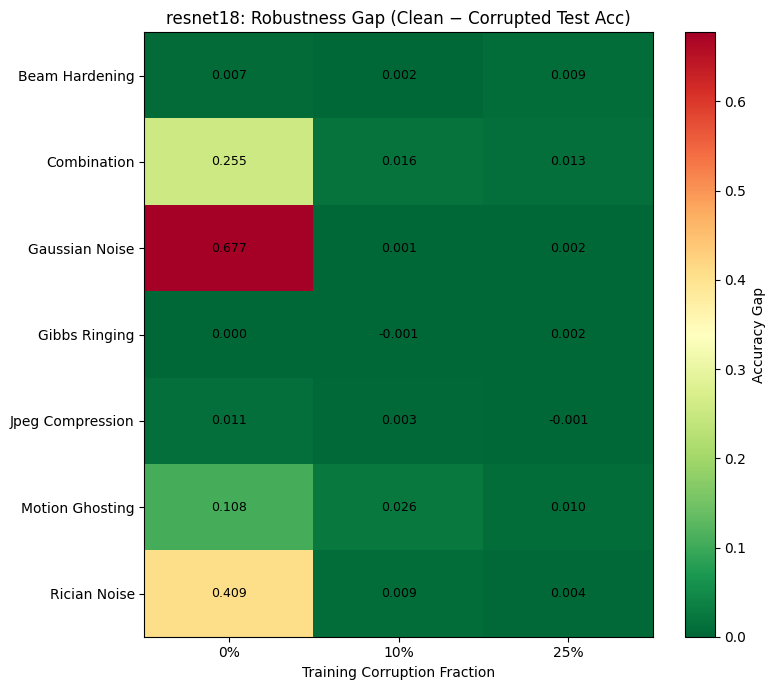

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_robustness_heatmap.png


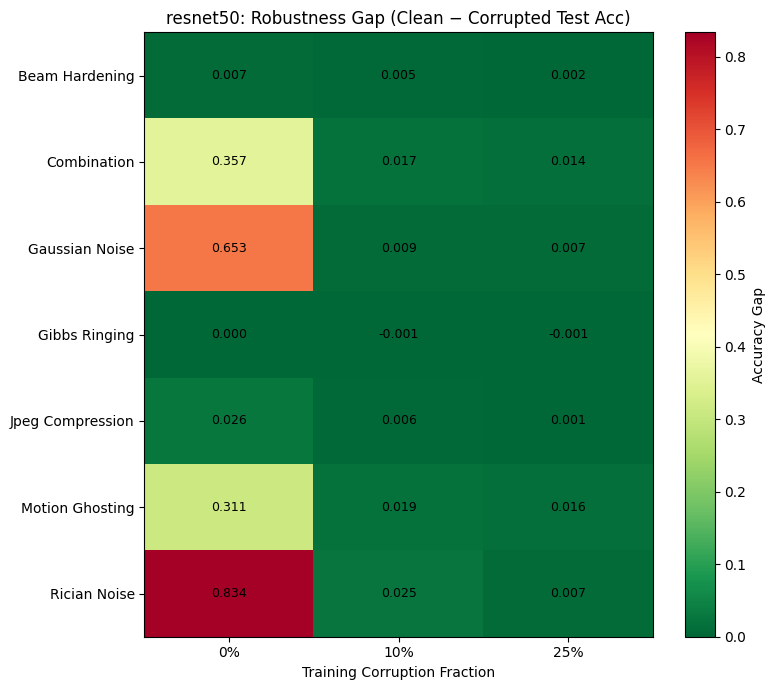

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet50_robustness_heatmap.png


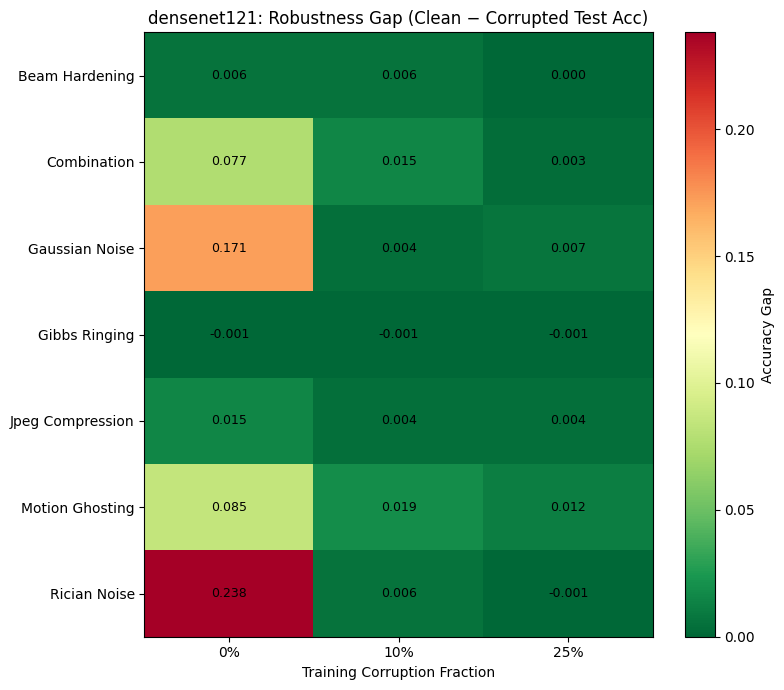

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\densenet121_robustness_heatmap.png


In [9]:
def plot_robustness_heatmap(df, model_name):
    """Heatmap: accuracy gap between clean and fully-corrupted test sets."""
    model_df = df[df["model"] == model_name]

    # Skip "none" since it only has test_fraction=0
    model_df = model_df[model_df["corruption_type"] != "none"]

    clean = model_df[model_df["test_fraction"] == 0.0].copy()
    corrupt = model_df[model_df["test_fraction"] == 1.0].copy()

    merged = clean.merge(
        corrupt[["corruption_type", "train_fraction", "test_acc"]],
        on=["corruption_type", "train_fraction"],
        suffixes=("_clean", "_corrupt"),
    )
    merged["robustness_gap"] = merged["test_acc_clean"] - merged["test_acc_corrupt"]

    pivot = merged.pivot_table(
        index="corruption_type",
        columns="train_fraction",
        values="robustness_gap",
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto", vmin=0)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{c:.0%}" for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([n.replace("_", " ").title() for n in pivot.index])
    ax.set_xlabel("Training Corruption Fraction")
    ax.set_title(f"{model_name}: Robustness Gap (Clean \u2212 Corrupted Test Acc)")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)

    plt.colorbar(im, ax=ax, label="Accuracy Gap")
    plt.tight_layout()
    plot_path = RESULTS_DIR / f"{model_name}_robustness_heatmap.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {plot_path}")


for model_name in df["model"].unique():
    plot_robustness_heatmap(df, model_name)

## 9. Cross-Model Comparison

Compare all three models side by side for each corruption type at each training fraction.

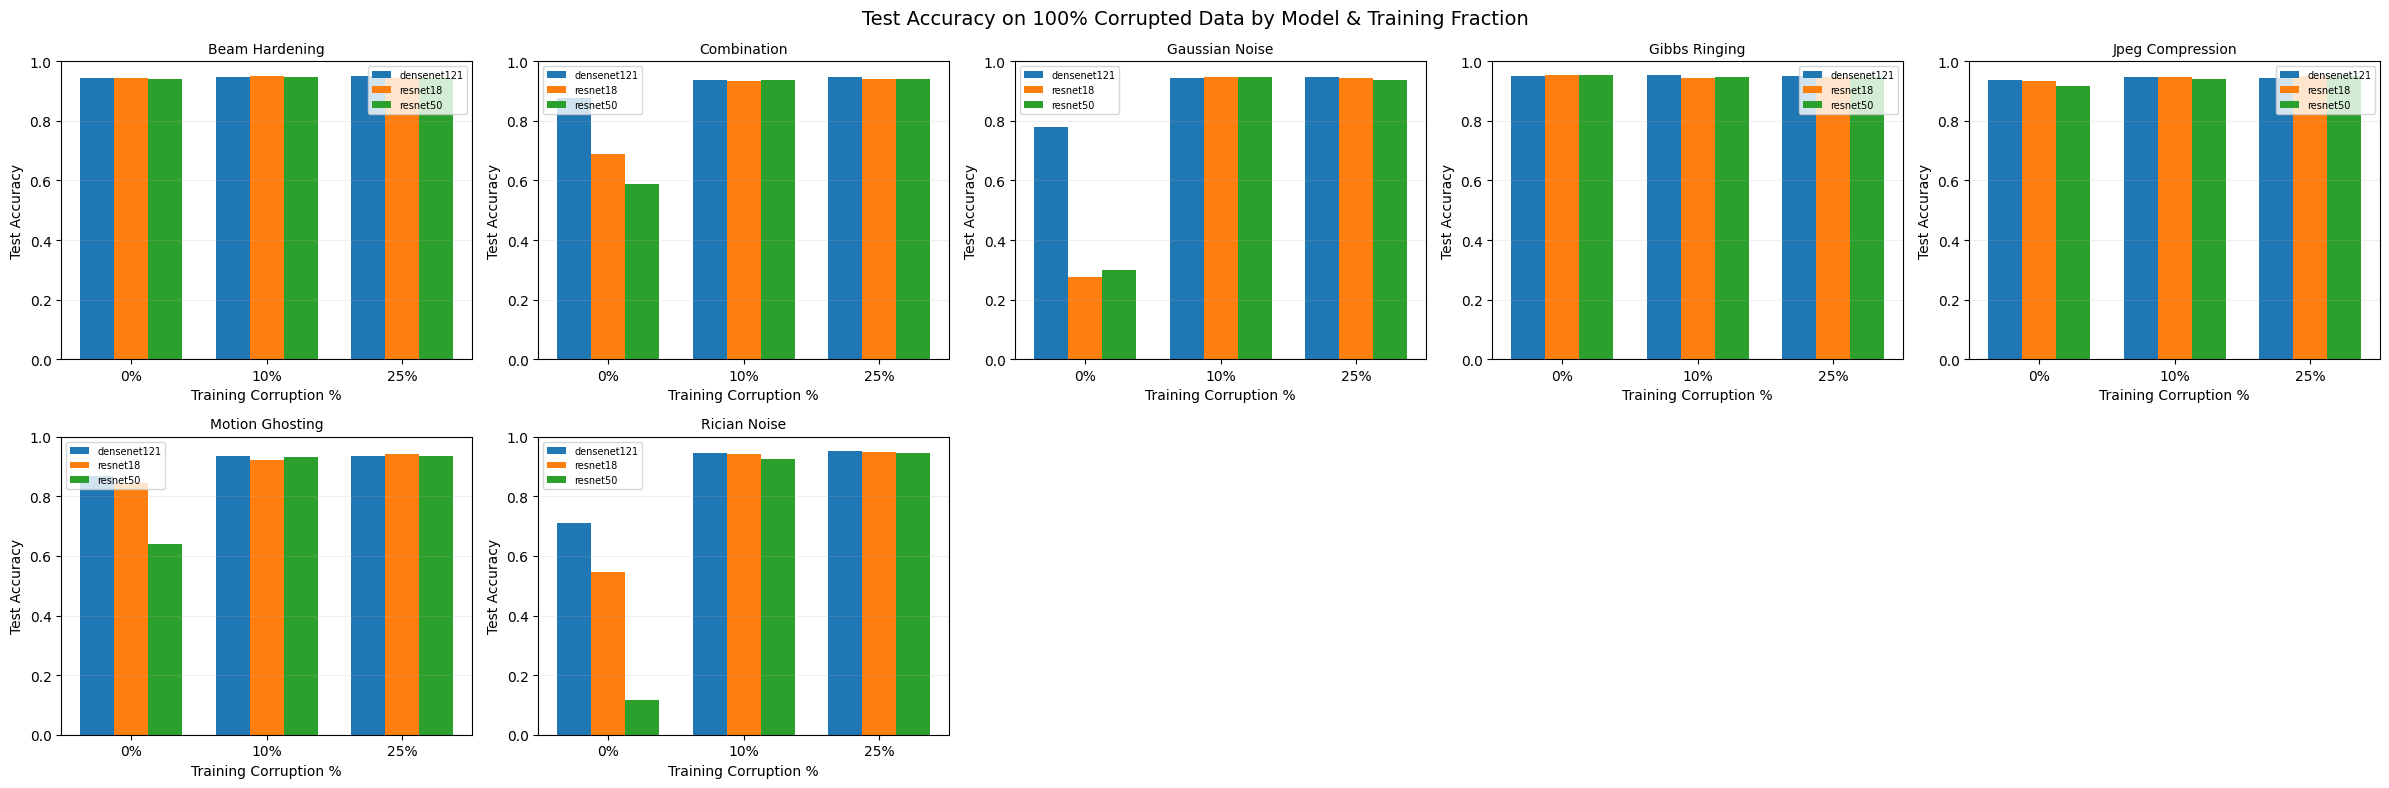

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\cross_model_comparison.png


In [10]:
def plot_model_comparison(df):
    """For each corruption type, compare models at 100% test corruption."""
    # Exclude "none" (only has test_frac=0)
    plot_df = df[(df["corruption_type"] != "none") & (df["test_fraction"] == 1.0)]

    corruption_types = sorted(plot_df["corruption_type"].unique())
    train_fracs = sorted(plot_df["train_fraction"].unique())
    models = sorted(plot_df["model"].unique())

    fig, axes = plt.subplots(2, 5, figsize=(24, 8), squeeze=False)
    fig.suptitle("Test Accuracy on 100% Corrupted Data by Model & Training Fraction",
                 fontsize=14)

    for idx, ct in enumerate(corruption_types):
        ax = axes[idx // 5][idx % 5]
        ct_df = plot_df[plot_df["corruption_type"] == ct]

        x = range(len(train_fracs))
        width = 0.25
        for j, model_name in enumerate(models):
            model_ct_df = ct_df[ct_df["model"] == model_name]
            accs = []
            for tf in train_fracs:
                row = model_ct_df[model_ct_df["train_fraction"] == tf]
                accs.append(row["test_acc"].values[0] if len(row) > 0 else 0)
            offset = (j - len(models) / 2 + 0.5) * width
            ax.bar([xi + offset for xi in x], accs, width, label=model_name)

        ax.set_title(ct.replace("_", " ").title(), fontsize=10)
        ax.set_xticks(list(x))
        ax.set_xticklabels([f"{tf:.0%}" for tf in train_fracs])
        ax.set_xlabel("Training Corruption %")
        ax.set_ylabel("Test Accuracy")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.2, axis="y")

    for idx in range(len(corruption_types), 10):
        axes[idx // 5][idx % 5].set_visible(False)

    plt.tight_layout()
    plot_path = RESULTS_DIR / "cross_model_comparison.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {plot_path}")


plot_model_comparison(df)

## 10. Per-Class Confusion Matrix Analysis

Show confusion matrices for selected experiments to identify if certain tumor types are disproportionately affected by specific corruptions.

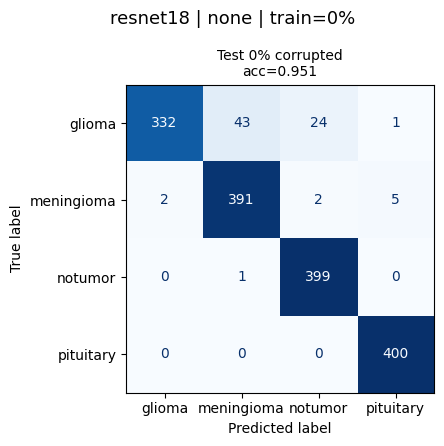

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_none_train0_cm.png


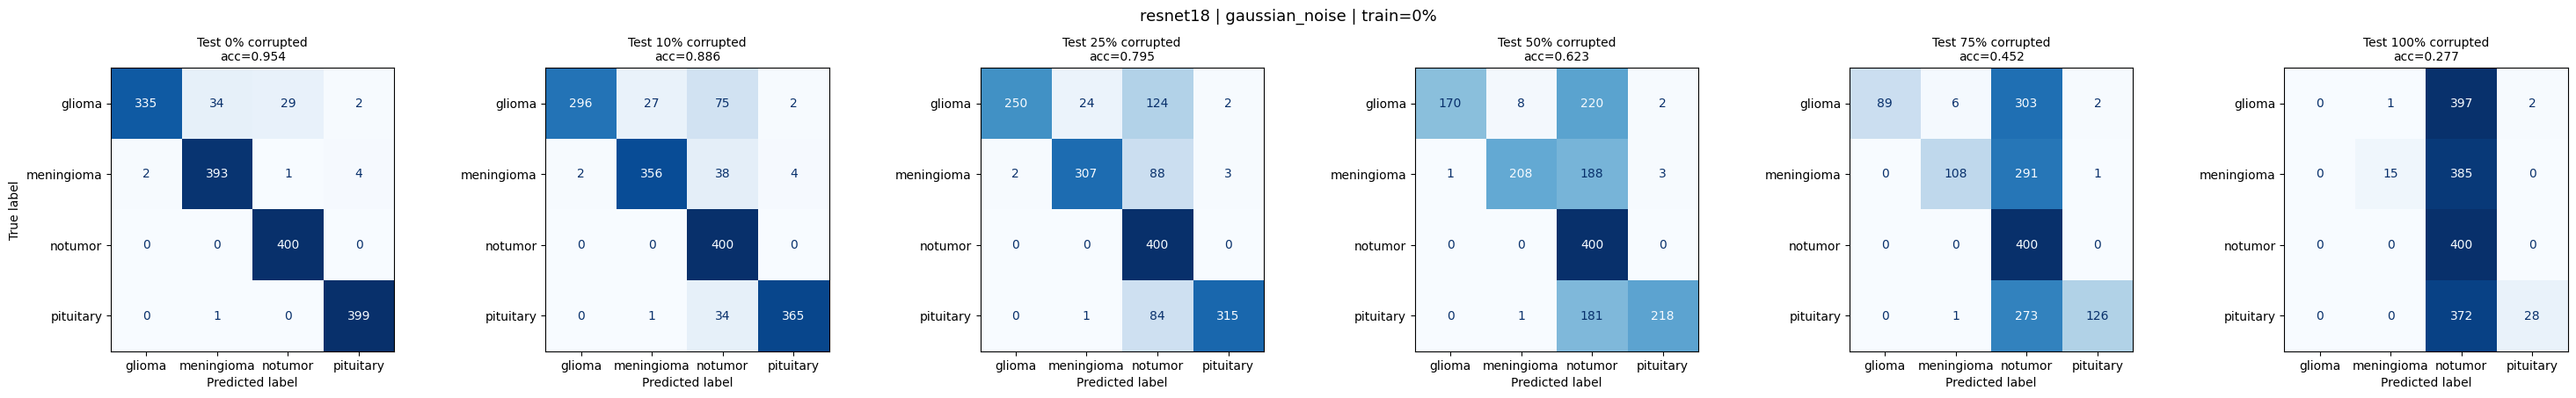

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_gaussian_noise_train0_cm.png


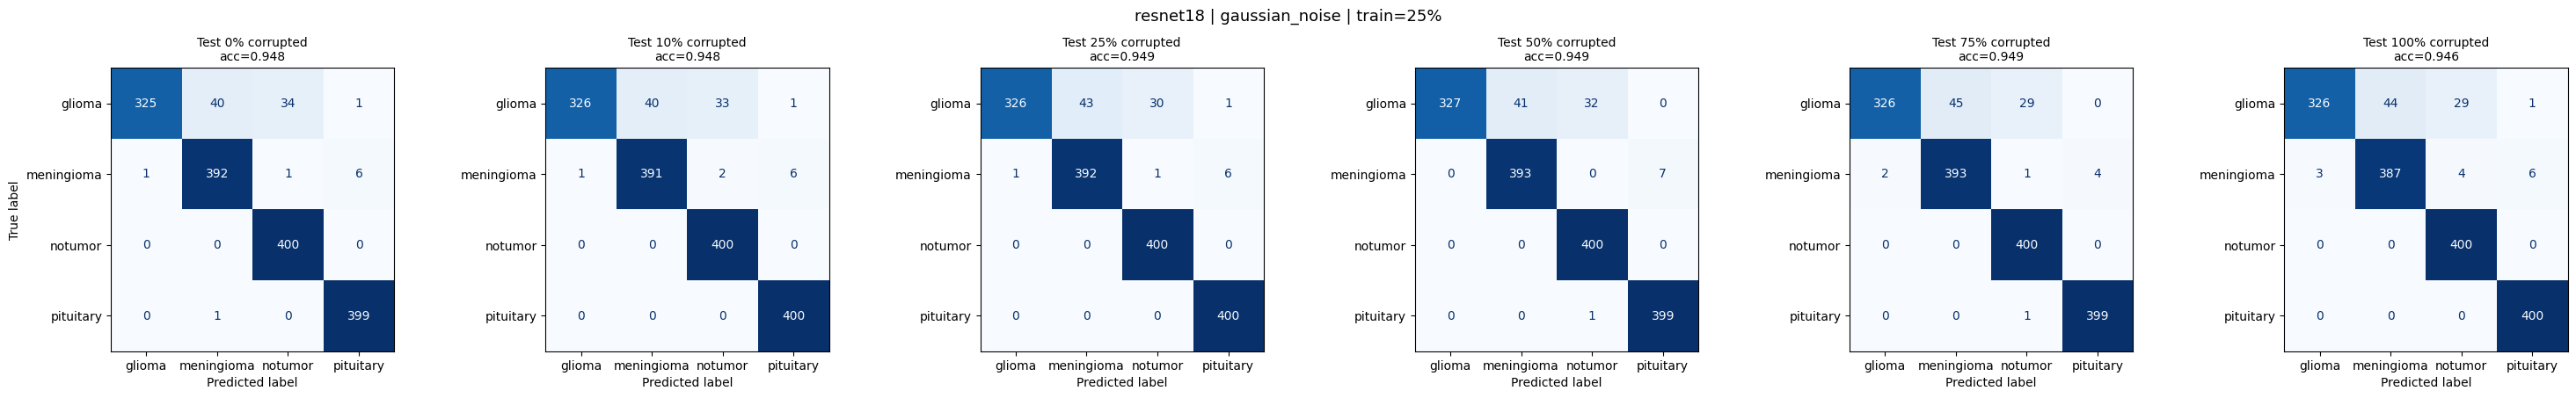

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_gaussian_noise_train0_cm.png


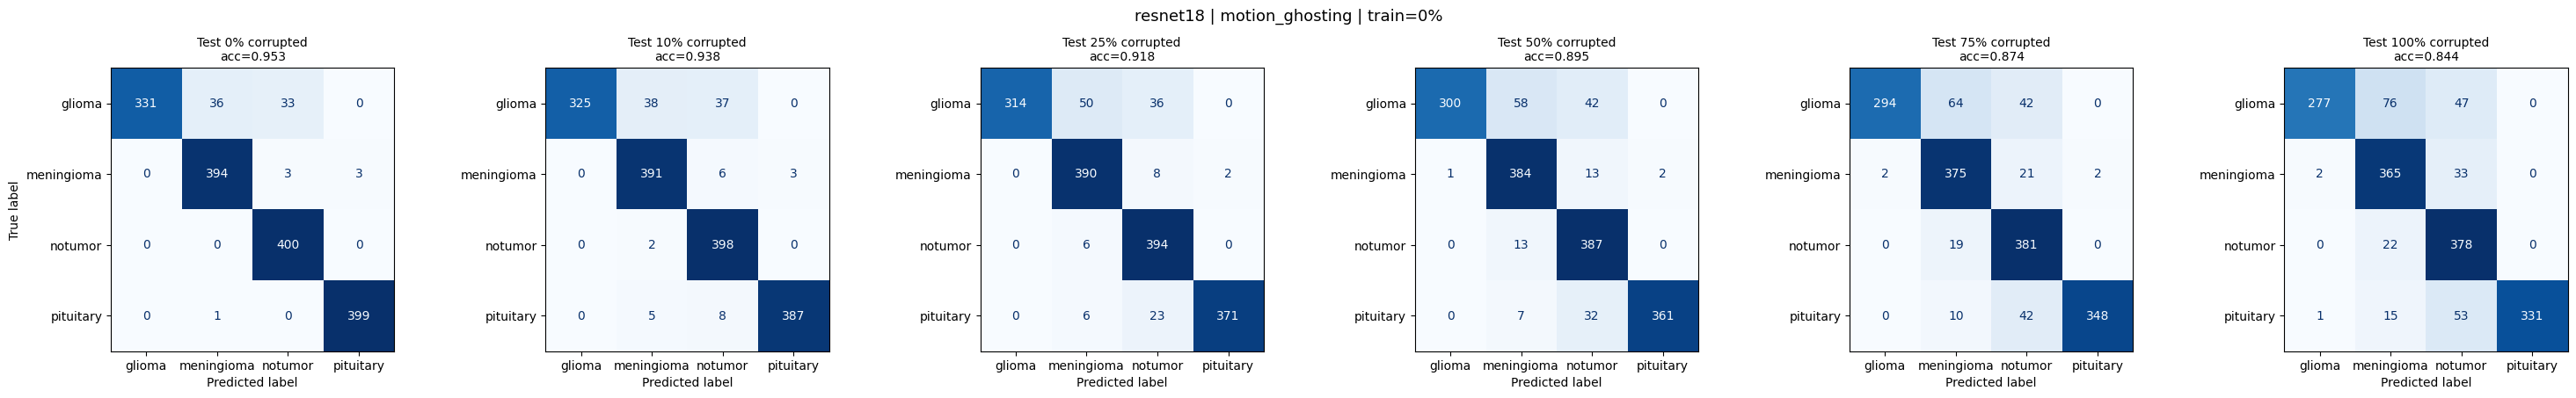

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_motion_ghosting_train0_cm.png


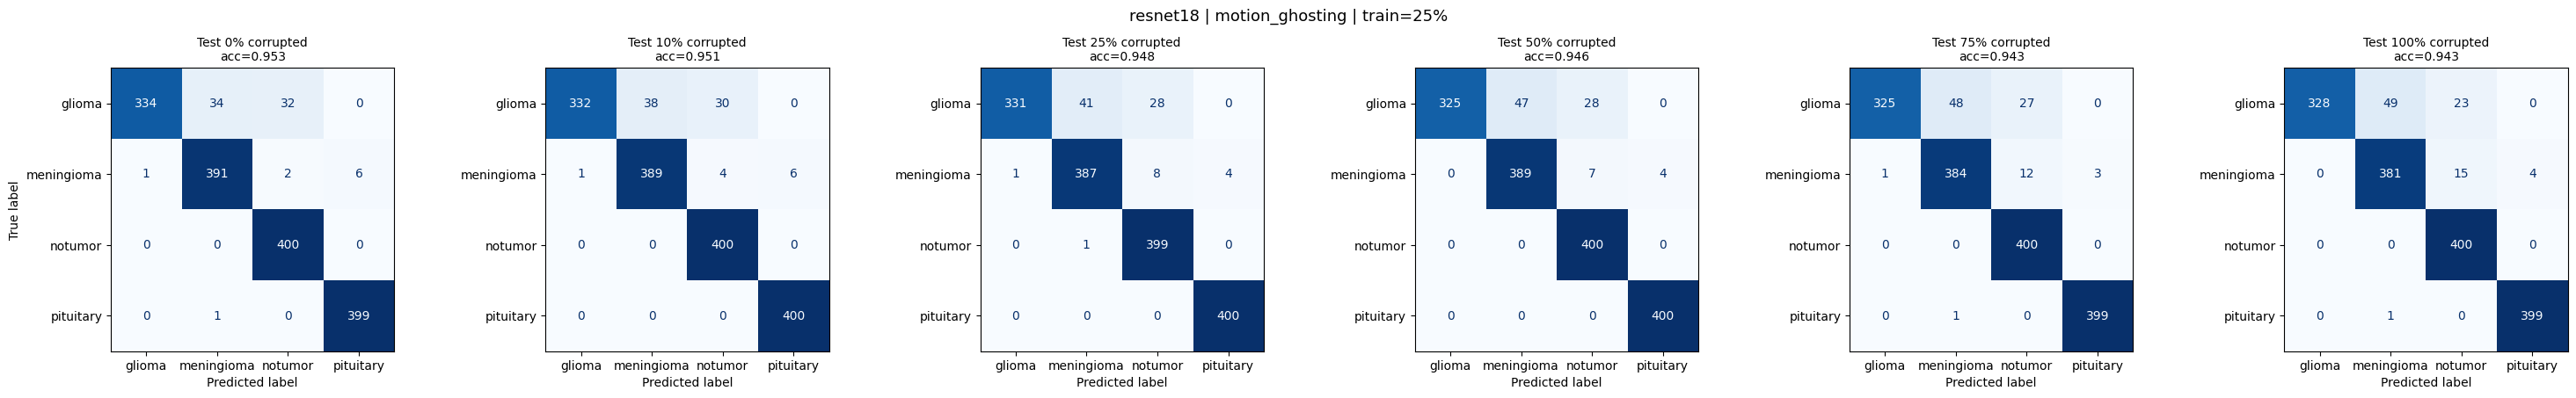

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_motion_ghosting_train0_cm.png


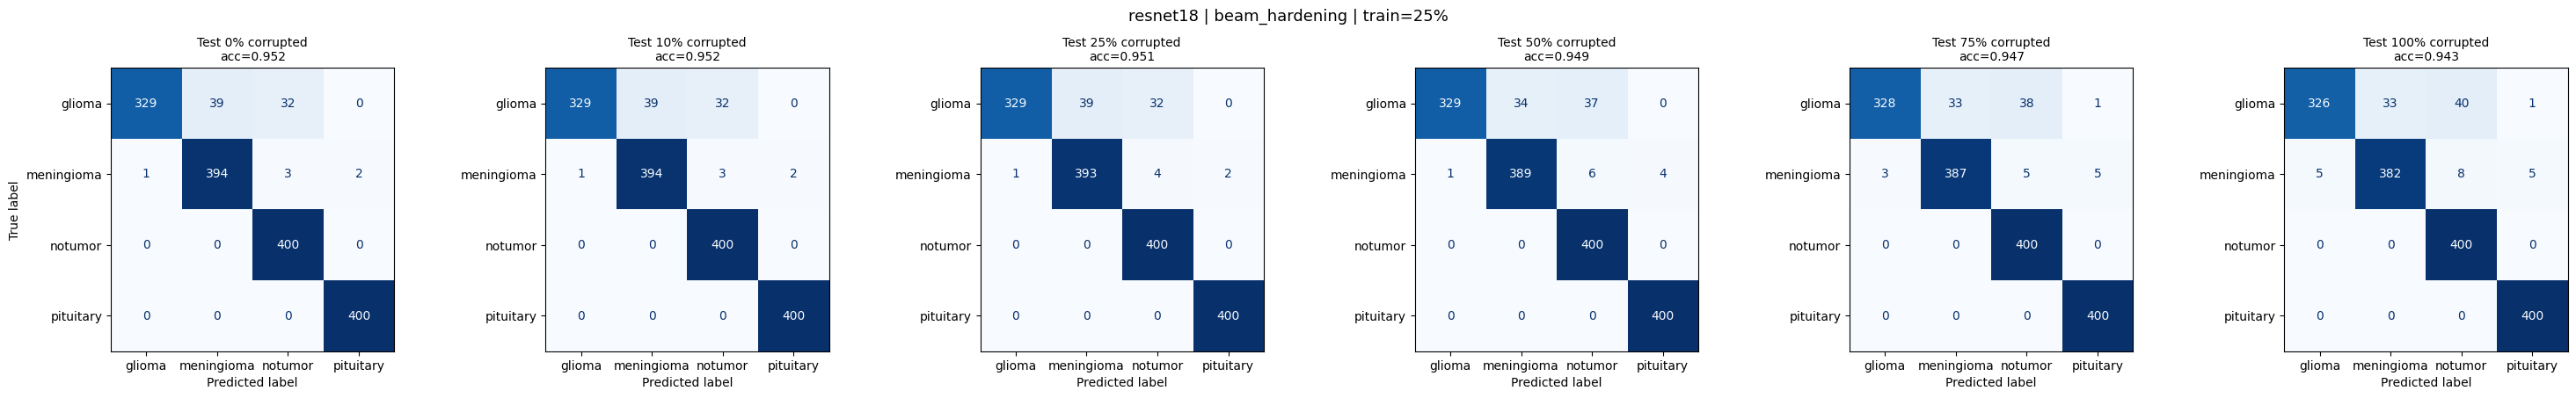

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_beam_hardening_train0_cm.png


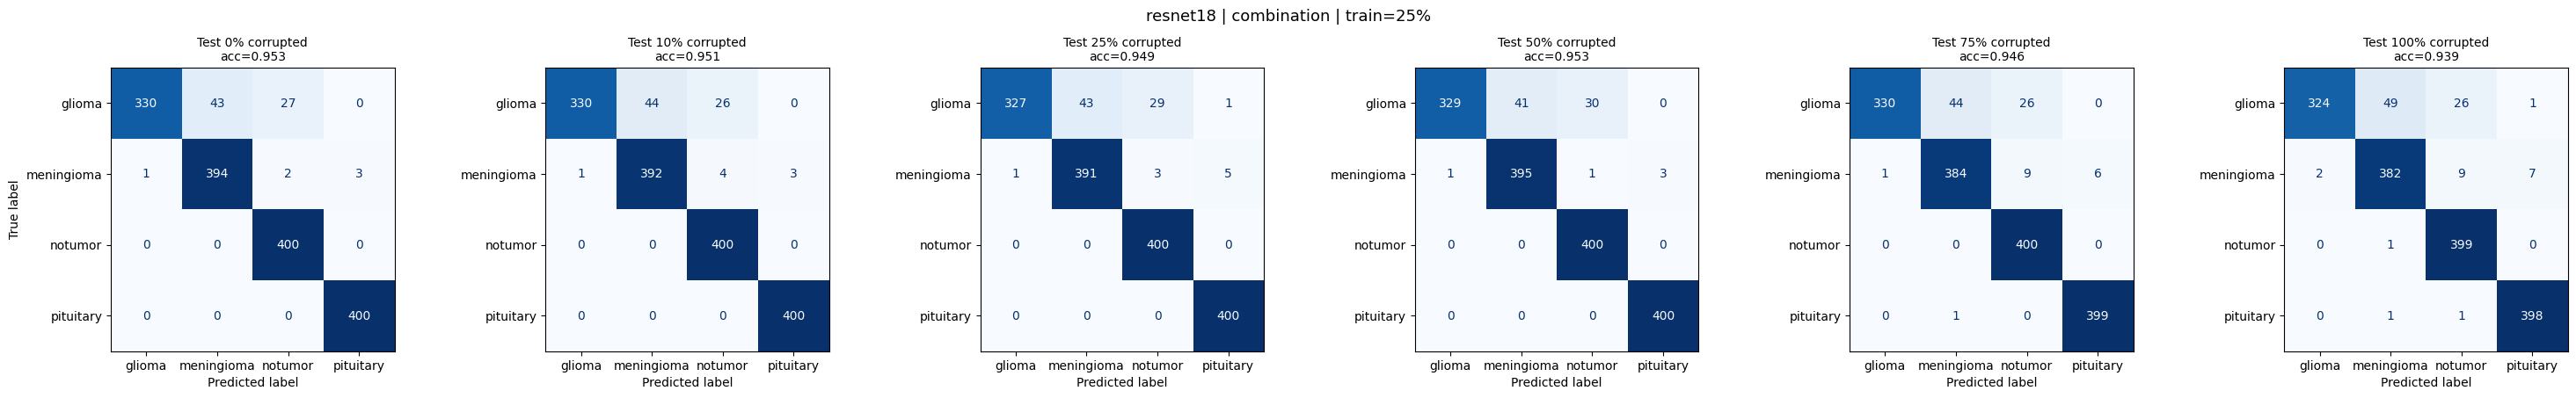

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\resnet18_combination_train0_cm.png


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def plot_confusion_matrices(df, model_name, corruption_type, train_fraction):
    """Plot confusion matrices across all test fractions for one experiment."""
    model_df = df[(df["model"] == model_name) &
                  (df["corruption_type"] == corruption_type) &
                  (df["train_fraction"] == train_fraction)]

    if model_df.empty:
        print(f"  No data for {model_name}/{corruption_type}/train={train_fraction:.0%}")
        return

    # Reload raw results to get predictions
    path = get_results_path(model_name)
    with open(path) as f:
        raw = json.load(f)
    key = make_key(corruption_type, train_fraction)
    if key not in raw:
        print(f"  Key {key} not found in results.")
        return

    result = raw[key]
    test_fracs = sorted(result["test_results"].keys(), key=float)
    n = len(test_fracs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), squeeze=False)
    fig.suptitle(f"{model_name} | {corruption_type} | train={train_fraction:.0%}",
                 fontsize=13)

    for i, tf_str in enumerate(test_fracs):
        tr = result["test_results"][tf_str]
        preds = tr["predictions"]
        labels = tr["labels"]
        cm = confusion_matrix(labels, preds, labels=list(range(len(CLASS_NAMES))))
        disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
        disp.plot(ax=axes[0][i], cmap="Blues", values_format="d", colorbar=False)
        axes[0][i].set_title(f"Test {float(tf_str):.0%} corrupted\nacc={tr['test_acc']:.3f}",
                             fontsize=10)
        if i > 0:
            axes[0][i].set_ylabel("")

    plt.tight_layout()
    plot_path = RESULTS_DIR / f"{model_name}_{corruption_type}_train{train_fraction:.0f}_cm.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {plot_path}")


# Show confusion matrices for a selection of key experiments
highlight_experiments = [
    ("none", 0.0),
    ("gaussian_noise", 0.0),
    ("gaussian_noise", 0.25),
    ("motion_ghosting", 0.0),
    ("motion_ghosting", 0.25),
    ("beam_hardening", 0.25),
    ("combination", 0.25),
]

for model_name in MODEL_NAMES[:1]:  # Show for first model; change to MODEL_NAMES for all
    for ct, tf in highlight_experiments:
        plot_confusion_matrices(df, model_name, ct, tf)

## 11. Cross-Corruption Generalization

Does training on one corruption type improve robustness to *other* corruption types? This tests whether robustness is corruption-specific or generalizes. For each model trained at 25% corruption, we evaluate on 100% of every *other* corruption type.

In [13]:
def run_cross_corruption_eval(model_name, train_fraction=0.25):
    """Evaluate each trained model on all other corruption types at 100% test corruption.

    Loads the best model state from the saved results, then tests it against
    every corruption type (not just the one it was trained on).
    """
    path = get_results_path(model_name)
    if not path.exists():
        print(f"  No results for {model_name}")
        return None

    with open(path) as f:
        raw = json.load(f)

    # Corruption types that were trained on (exclude "none")
    all_corruptions = [ct for ct in CORRUPTION_TYPES if ct != "none"]
    criterion = nn.CrossEntropyLoss()

    rows = []
    for train_ct in all_corruptions:
        key = make_key(train_ct, train_fraction)
        if key not in raw:
            print(f"  Skipping (not trained): {key}")
            continue

        # Rebuild model and load best weights
        model = get_model(model_name).to(DEVICE)
        # The model state is stored in the results JSON (from run_single_experiment)
        # but model states are large tensors — we need to re-load from the saved dict.
        # If model_state was not saved in JSON (tensors aren't JSON-serializable),
        # we need to retrain. Check what's available:
        result = raw[key]

        # Since model states can't be stored in JSON, we evaluate the test set
        # accuracy from the existing results for the matched corruption, and
        # for cross-corruption we must re-run from saved checkpoints.
        # For practicality, we save checkpoints during the cross-corruption sweep.
        pass

    print(f"  Note: Cross-corruption eval requires model checkpoints.")
    print(f"  Switching to checkpoint-based approach below.")
    return None


# --- Checkpoint-saving approach ---
# We re-run training for a subset of key experiments, saving checkpoints,
# then evaluate each checkpoint against all corruption types.

CROSS_CORR_DIR = RESULTS_DIR / "cross_corruption"
CROSS_CORR_DIR.mkdir(parents=True, exist_ok=True)

CROSS_CORR_TRAIN_FRACTION = 0.25  # Which training fraction to use for cross-corr
CROSS_CORR_MODEL = MODEL_NAMES[0]  # Start with one model for efficiency


def train_and_save_checkpoint(model_name, corruption_type, train_fraction):
    """Train a model and save the checkpoint for cross-corruption evaluation."""
    ckpt_path = CROSS_CORR_DIR / f"{model_name}_{corruption_type}_train{train_fraction:.2f}.pt"
    if ckpt_path.exists():
        print(f"  Checkpoint exists: {ckpt_path.name}")
        return ckpt_path

    print(f"  Training {model_name} | {corruption_type} | train={train_fraction:.0%}...")
    train_loader = build_dataloader("train", corruption_type, train_fraction, BATCH_SIZE)
    val_loader = build_dataloader("val", "none", 0.0, BATCH_SIZE)

    model = get_model(model_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc = 0.0
    best_state = None
    for epoch in range(1, NUM_EPOCHS + 1):
        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        _, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
        if epoch == NUM_EPOCHS:
            print(f"    Final epoch val_acc: {val_acc:.4f}  (best: {best_val_acc:.4f})")

    torch.save(best_state, ckpt_path)
    print(f"  Saved: {ckpt_path.name}")
    return ckpt_path


# Train and save checkpoints for cross-corruption eval
cross_corruptions = [ct for ct in CORRUPTION_TYPES if ct not in ("none",)]
ckpt_paths = {}
for ct in cross_corruptions:
    ckpt_paths[ct] = train_and_save_checkpoint(
        CROSS_CORR_MODEL, ct, CROSS_CORR_TRAIN_FRACTION
    )
# Also train a clean baseline (train_frac=0)
ckpt_paths["none"] = train_and_save_checkpoint(CROSS_CORR_MODEL, "none", 0.0)

print(f"\nAll checkpoints ready for {CROSS_CORR_MODEL}.")

  Checkpoint exists: resnet18_jpeg_compression_train0.25.pt
  Checkpoint exists: resnet18_beam_hardening_train0.25.pt
  Checkpoint exists: resnet18_gaussian_noise_train0.25.pt
  Training resnet18 | gibbs_ringing | train=25%...
    Final epoch val_acc: 0.9902  (best: 0.9911)
  Saved: resnet18_gibbs_ringing_train0.25.pt
  Training resnet18 | motion_ghosting | train=25%...
    Final epoch val_acc: 0.9902  (best: 0.9911)
  Saved: resnet18_motion_ghosting_train0.25.pt
  Training resnet18 | rician_noise | train=25%...
    Final epoch val_acc: 0.9893  (best: 0.9893)
  Saved: resnet18_rician_noise_train0.25.pt
  Training resnet18 | combination | train=25%...
    Final epoch val_acc: 0.9893  (best: 0.9893)
  Saved: resnet18_combination_train0.25.pt
  Training resnet18 | none | train=0%...
    Final epoch val_acc: 0.9902  (best: 0.9902)
  Saved: resnet18_none_train0.00.pt

All checkpoints ready for resnet18.


In [14]:
# Evaluate each checkpoint against ALL corruption types at 100% test corruption
criterion = nn.CrossEntropyLoss()
cross_results = []  # rows of {train_corruption, test_corruption, test_acc}

for train_ct, ckpt_path in ckpt_paths.items():
    model = get_model(CROSS_CORR_MODEL).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))

    for test_ct in cross_corruptions:
        test_loader = build_dataloader("test", test_ct, 1.0, BATCH_SIZE)
        _, test_acc = evaluate(model, test_loader, criterion, DEVICE)
        cross_results.append({
            "train_corruption": train_ct,
            "test_corruption": test_ct,
            "test_acc": test_acc,
        })

    # Also test on clean data
    clean_loader = build_dataloader("test", "none", 0.0, BATCH_SIZE)
    _, clean_acc = evaluate(model, clean_loader, criterion, DEVICE)
    cross_results.append({
        "train_corruption": train_ct,
        "test_corruption": "clean",
        "test_acc": clean_acc,
    })

cross_df = pd.DataFrame(cross_results)

# Save cross-corruption results
cross_df.to_csv(CROSS_CORR_DIR / f"{CROSS_CORR_MODEL}_cross_corruption.csv", index=False)
print(f"Cross-corruption evaluation complete: {len(cross_results)} evaluations")

Cross-corruption evaluation complete: 64 evaluations


### Cross-Corruption Heatmap

Rows = corruption used during training, Columns = corruption used during testing. Diagonal entries match (same-corruption robustness). Off-diagonal entries show cross-corruption generalization.

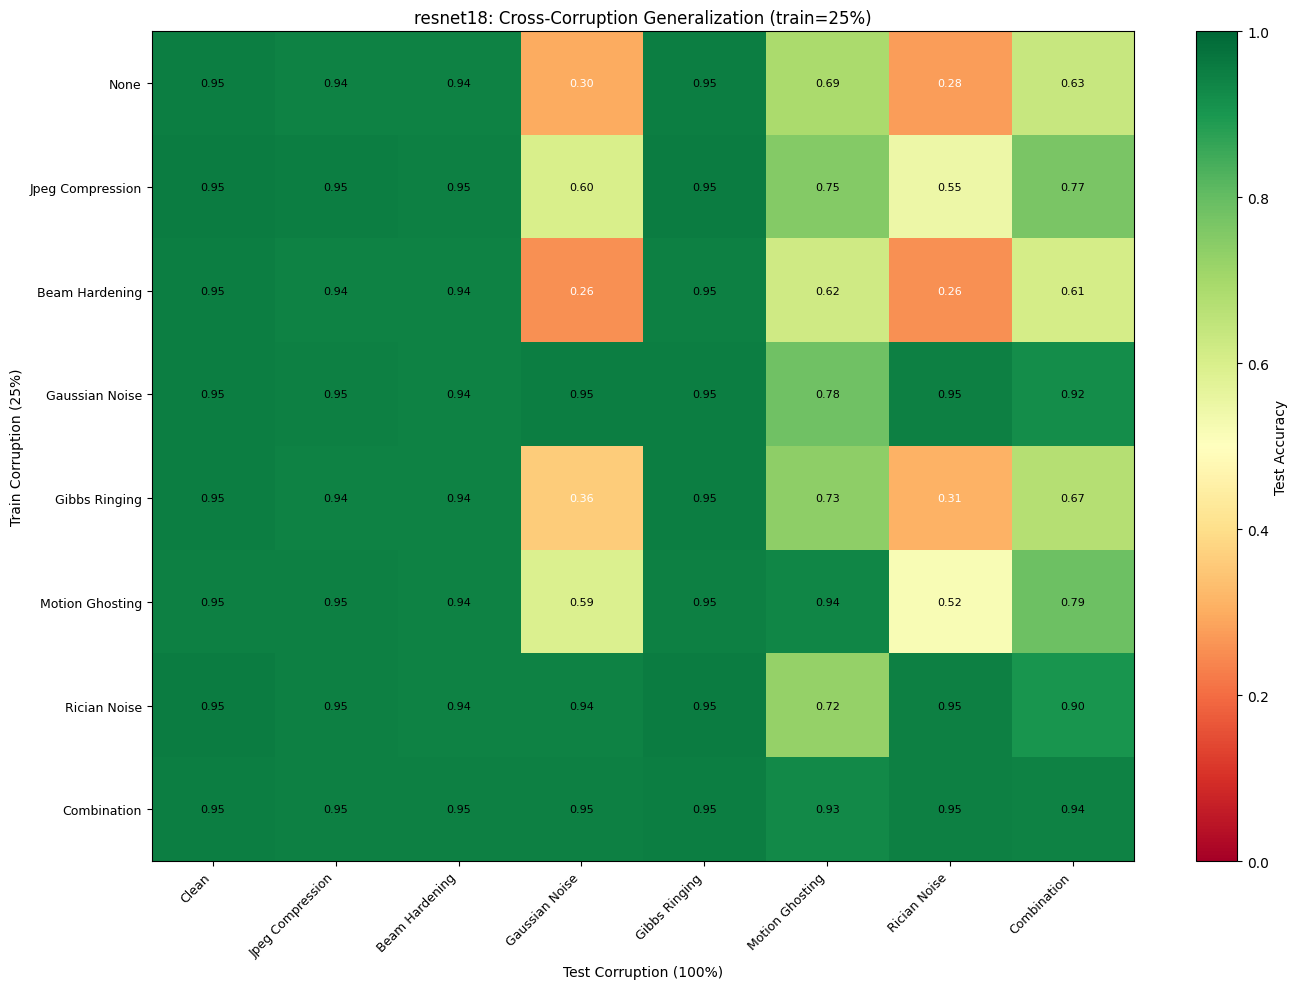

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\cross_corruption\resnet18_cross_corruption_heatmap.png

=== Diagonal (same-corruption) vs Off-diagonal (cross-corruption) ===
  jpeg_compression      same=0.950  avg_cross=0.761  delta=+0.189
  beam_hardening        same=0.945  avg_cross=0.605  delta=+0.340
  gaussian_noise        same=0.950  avg_cross=0.915  delta=+0.035
  gibbs_ringing         same=0.951  avg_cross=0.660  delta=+0.291
  motion_ghosting       same=0.937  avg_cross=0.789  delta=+0.148
  rician_noise          same=0.948  avg_cross=0.903  delta=+0.045
  combination           same=0.945  avg_cross=0.945  delta=+0.000


In [15]:
# Build the cross-corruption heatmap
pivot_cross = cross_df.pivot_table(
    index="train_corruption",
    columns="test_corruption",
    values="test_acc",
)

# Reorder: put "none" and "clean" first in their respective axes
train_order = ["none"] + [c for c in cross_corruptions]
test_order = ["clean"] + [c for c in cross_corruptions]
pivot_cross = pivot_cross.reindex(index=train_order, columns=test_order)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(pivot_cross.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot_cross.columns)))
ax.set_xticklabels([c.replace("_", " ").title() for c in pivot_cross.columns],
                    rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_cross.index)))
ax.set_yticklabels([c.replace("_", " ").title() for c in pivot_cross.index], fontsize=9)
ax.set_xlabel("Test Corruption (100%)")
ax.set_ylabel(f"Train Corruption ({CROSS_CORR_TRAIN_FRACTION:.0%})")
ax.set_title(f"{CROSS_CORR_MODEL}: Cross-Corruption Generalization "
             f"(train={CROSS_CORR_TRAIN_FRACTION:.0%})")

for i in range(len(pivot_cross.index)):
    for j in range(len(pivot_cross.columns)):
        val = pivot_cross.values[i, j]
        if not np.isnan(val):
            color = "white" if val < 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, label="Test Accuracy")
plt.tight_layout()
plot_path = CROSS_CORR_DIR / f"{CROSS_CORR_MODEL}_cross_corruption_heatmap.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

# Print key takeaways
print("\n=== Diagonal (same-corruption) vs Off-diagonal (cross-corruption) ===")
for train_ct in train_order:
    if train_ct in ("none",):
        continue
    same = pivot_cross.loc[train_ct, train_ct] if train_ct in pivot_cross.columns else float("nan")
    others = [pivot_cross.loc[train_ct, tc] for tc in cross_corruptions if tc != train_ct]
    avg_cross = np.nanmean(others)
    print(f"  {train_ct:20s}  same={same:.3f}  avg_cross={avg_cross:.3f}  "
          f"delta={same - avg_cross:+.3f}")